In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/Fraud_Data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           588912 non-null  int64  
 1   is_fraud                 588912 non-null  int64  
 2   transaction_time         588912 non-null  int64  
 3   transaction_amount       588912 non-null  float64
 4   card_network             588912 non-null  object 
 5   card_type                588912 non-null  object 
 6   purchaser_email_domain   494686 non-null  object 
 7   device_type              140606 non-null  object 
 8   is_identity_seen_before  129173 non-null  object 
 9   user_os                  144028 non-null  object 
 10  user_browser             144028 non-null  object 
 11  environment              144028 non-null  object 
 12  environment_freq         144028 non-null  float64
 13  environment_risk         144028 non-null  float64
 14  devi

In [4]:
df = df.drop(columns=['device_os_invalid'])

In [5]:
df['transaction_time']

0            86400
1            86401
2            86469
3            86499
4            86506
            ...   
588907    15811047
588908    15811049
588909    15811079
588910    15811088
588911    15811131
Name: transaction_time, Length: 588912, dtype: int64

In [6]:
df['transaction_time'].max()

15811131

In [7]:
df['time_hour'] = (df['transaction_time'] // 3600) % 24
df['time_day']  = df['transaction_time'] / 86400
df['time_diff'] = df['transaction_time'].diff()
df['time_diff_min'] = df['time_diff'] / 60

In [8]:
df[['time_day', 'time_hour', 'time_diff_min']]

,time_day,time_hour,time_diff_min
0,1.000000,0,NaN
1,1.000012,0,0.016667
2,1.000799,0,1.133333
3,1.001146,0,0.500000
4,1.001227,0,0.116667
...,...,...,...
588907,182.998229,23,0.283333
588908,182.998252,23,0.033333
588909,182.998600,23,0.500000
588910,182.998704,23,0.150000


In [9]:
df['time_diff_min'].min()

0.0

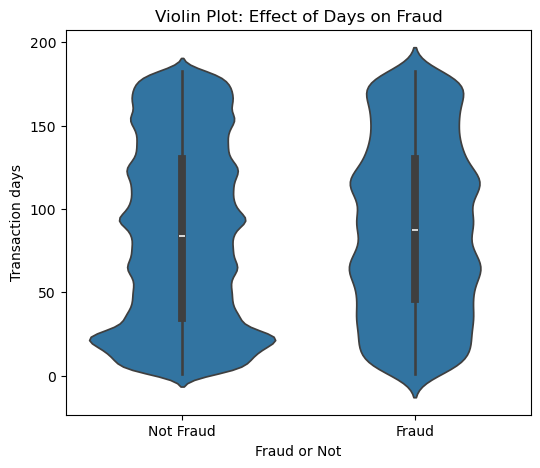

In [10]:
plt.figure(figsize=(6, 5))

sns.violinplot(
    data=df,
    x='is_fraud',
    y='time_day'
)

plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.xlabel('Fraud or Not')
plt.ylabel('Transaction days')
plt.title('Violin Plot: Effect of Days on Fraud')
plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588912 entries, 0 to 588911
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           588912 non-null  int64  
 1   is_fraud                 588912 non-null  int64  
 2   transaction_time         588912 non-null  int64  
 3   transaction_amount       588912 non-null  float64
 4   card_network             588912 non-null  object 
 5   card_type                588912 non-null  object 
 6   purchaser_email_domain   494686 non-null  object 
 7   device_type              140606 non-null  object 
 8   is_identity_seen_before  129173 non-null  object 
 9   user_os                  144028 non-null  object 
 10  user_browser             144028 non-null  object 
 11  environment              144028 non-null  object 
 12  environment_freq         144028 non-null  float64
 13  environment_risk         144028 non-null  float64
 14  card

In [12]:
df['amt_log'] = np.log1p(df['transaction_amount'])

In [13]:
df['amt_bins'] = pd.qcut(df['amt_log'], q =10 ,labels=False )

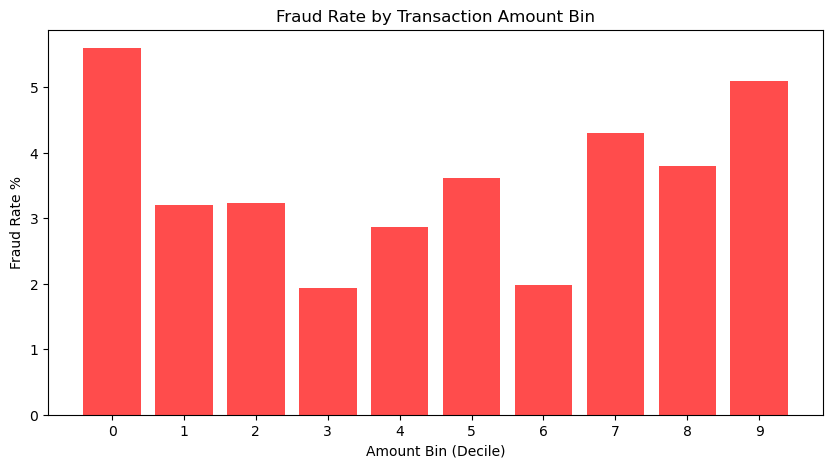

In [14]:
fraud_rate = df.groupby('amt_bins')['is_fraud'].mean() * 100

plt.figure(figsize=(10,5))
plt.bar(fraud_rate.index, fraud_rate.values, color='red', alpha=0.7)
plt.xlabel('Amount Bin (Decile)')
plt.ylabel('Fraud Rate %')
plt.title('Fraud Rate by Transaction Amount Bin')
plt.xticks(range(10))
plt.show()

In [15]:
df['time_diff'].describe()

count    588911.000000
mean         26.701371
std          59.584928
min           0.000000
25%           5.000000
50%          13.000000
75%          29.000000
max        4138.000000
Name: time_diff, dtype: float64

In [16]:
start = df.index[df['time_hour'] == 0][0]
end   = df.index[df['time_hour'] == 23][0]

df_first_day = df.loc[start:end]

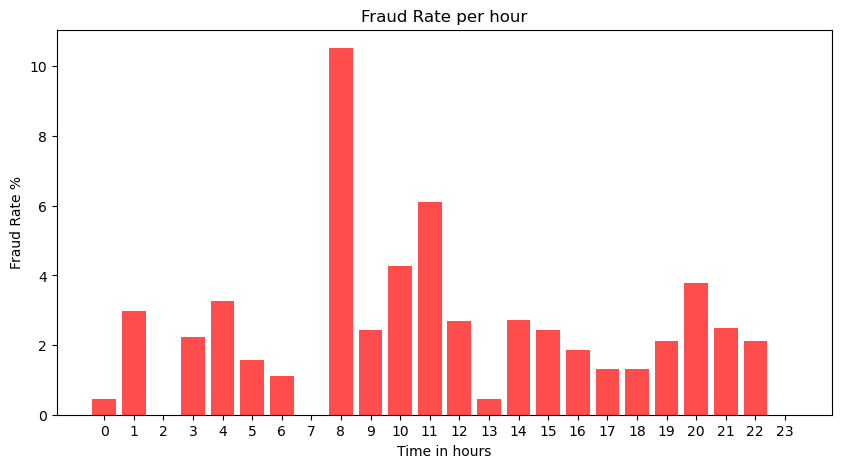

In [17]:
fraud_rate = df_first_day.groupby('time_hour')['is_fraud'].mean() * 100

plt.figure(figsize=(10,5))
plt.bar(fraud_rate.index, fraud_rate.values, color='red', alpha=0.7)
plt.xlabel('Time in hours')
plt.ylabel('Fraud Rate %')
plt.title('Fraud Rate per hour')
plt.xticks(range(24))
plt.show()

In [18]:
ct = pd.crosstab(df_first_day['time_hour'], df['is_fraud'])
ct * 100

is_fraud,0,1
time_hour,,
0,22700,100
1,19500,600
2,18000,0
3,13100,300
4,8900,300
5,6300,100
6,9000,100
7,6600,0
8,3400,400


In [19]:
chi2, p, dof, exp = chi2_contingency(ct)
print(p)

0.009648148408401221


In [20]:
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(cramers_v)

0.09359062560148748


In [21]:
df = df.copy()

# detect where cycle resets (hour drops, e.g., 23 → 0 or 24 → 1)
df['new_day'] = df['time_hour'].diff() < 0

# cumulative sum → gives day number
df['day_id'] = df['new_day'].cumsum()
pivot = df.pivot_table(
    index='time_hour',
    columns='day_id',
    values='is_fraud',  # replace this
    aggfunc='mean'
)
pivot.var(axis=1)

time_hour
0     0.000464
1     0.000517
2     0.001059
3     0.001182
4     0.002845
5     0.005265
6     0.006570
7     0.017540
8     0.011245
9     0.016008
10    0.012642
11    0.005956
12    0.001453
13    0.000461
14    0.000540
15    0.000434
16    0.000531
17    0.000465
18    0.000406
19    0.000485
20    0.000489
21    0.000415
22    0.000349
23    0.000598
dtype: float64

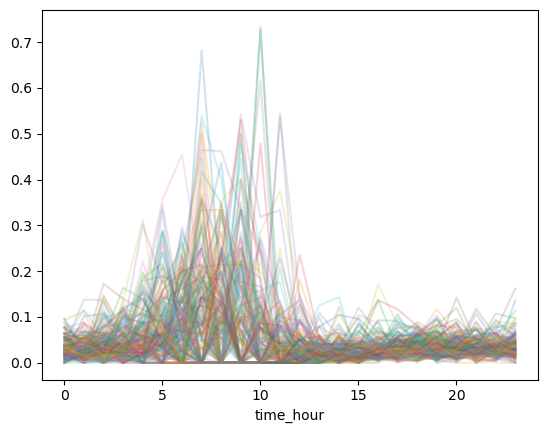

In [22]:
import matplotlib.pyplot as plt

pivot.plot(legend=False, alpha=0.2)
plt.show()

In [23]:
df['day_of_week'] = df['time_day'].astype(int) % 7

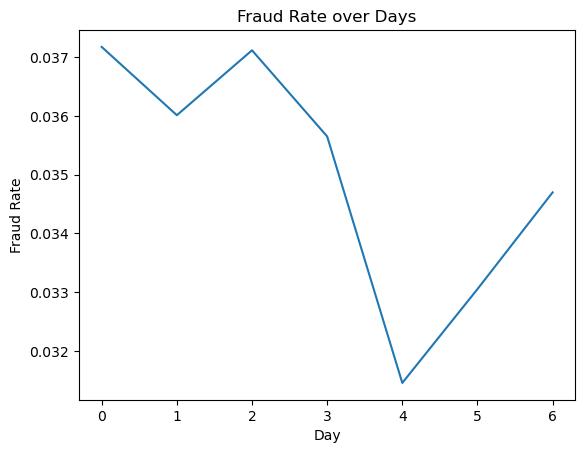

In [24]:
# fraud_by_day = df.groupby('day_id')['is_fraud'].mean()
fraud_by_day = df.groupby('day_of_week')['is_fraud'].mean()

plt.plot(fraud_by_day.index, fraud_by_day.values)
plt.xlabel('Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate over Days')
plt.show()

In [25]:
df['time_diff_log'] = np.log1p(df['time_diff'])

In [28]:
for i in df.columns:
    print(i)

transaction_id
is_fraud
transaction_time
transaction_amount
card_network
card_type
purchaser_email_domain
device_type
is_identity_seen_before
user_os
user_browser
environment
environment_freq
environment_risk
card_info
time_hour
time_day
time_diff
time_diff_min
amt_log
amt_bins
new_day
day_id
day_of_week
time_diff_log


In [27]:
df['new_day'].unique()

array([False,  True])